用来画图说明τ和曲线斜率并没有单调性

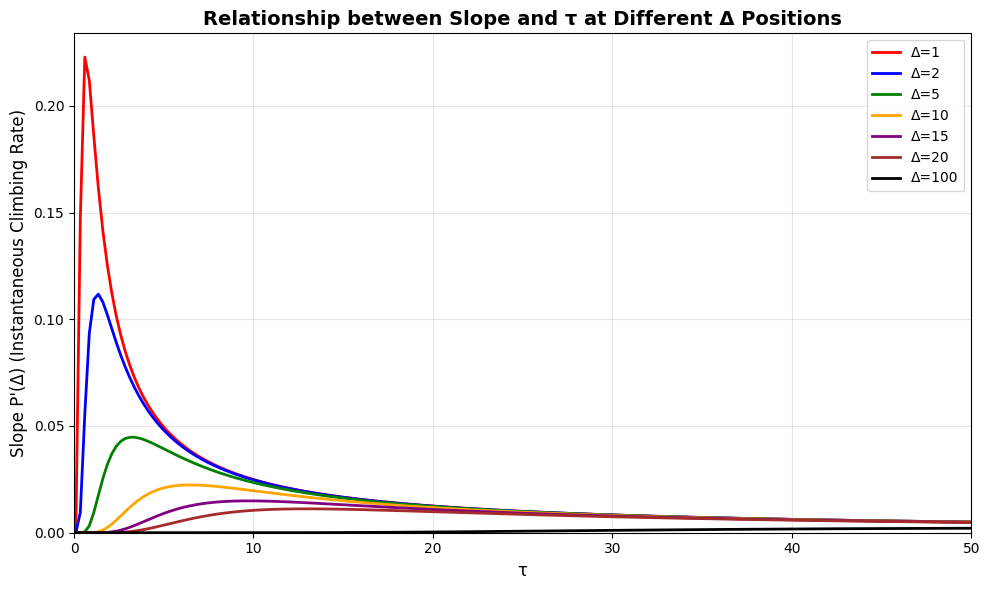

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress irrelevant warnings

# ===================== Core Parameter Settings =====================
x0 = 0          # Inflection point position (fixed)
A = 1           # Maximum value of the curve (fixed)
delta_list = [1, 2, 5, 10, 15, 20, 100]  # Specified Δ values
tau_range = np.linspace(0.1, 50, 200)  # τ value range (0.1 to 50, covering full trend)
# Extended color list to match delta_list length
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'black']  
labels = [f'Δ={d}' for d in delta_list]  # Legend labels

# ===================== Define Slope Calculation Function =====================
def logistic_derivative(delta, tau, x0=x0, A=A):
    """Calculate the slope (first derivative) of Logistic function at specified Δ and τ"""
    z = (delta - x0) / tau
    exp_term = np.exp(-z)
    derivative = (A / tau) * (exp_term / (1 + exp_term)**2)
    return derivative

# ===================== Calculation and Plotting =====================
plt.figure(figsize=(10, 6), dpi=100)

# Iterate over each Δ value, calculate slopes for different τ and plot
for delta, color, label in zip(delta_list, colors, labels):
    slope_values = logistic_derivative(delta, tau_range)
    plt.plot(tau_range, slope_values, color=color, label=label, linewidth=2)

# ===================== Plot Styling (Paper-level) =====================
plt.xlabel('τ', fontsize=12)
plt.ylabel('Slope P\'(Δ) (Instantaneous Climbing Rate)', fontsize=12)
plt.title('Relationship between Slope and τ at Different Δ Positions', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(0, 50)  # X-axis range
plt.ylim(bottom=0)  # Slope is non-negative, Y-axis starts from 0

plt.tight_layout()  # Auto-adjust layout
plt.show()